
Testing MLP with hidden_layers=[8], activation=relu


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9667
Test Loss: 0.1966

Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.9667
Test Loss: 0.1973

Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.9333
Test Loss: 0.3858

Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 1.0000
Test Loss: 0.0762

Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 0.9667
Test Loss: 0.0801

Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.9000
Test Loss: 0.4825

Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 1.0000
Test Loss: 0.0524

Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 1.0000
Test Loss: 0.0482

Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9333
Test Loss: 0.3243

========== FINAL RESULTS ==========
Hidden Layers: [8], Activation: relu, Accuracy: 0.9667, Loss: 0.1966
Hidden Layers: [8], Activation: tanh, Accuracy: 0.9667, Loss: 0.1

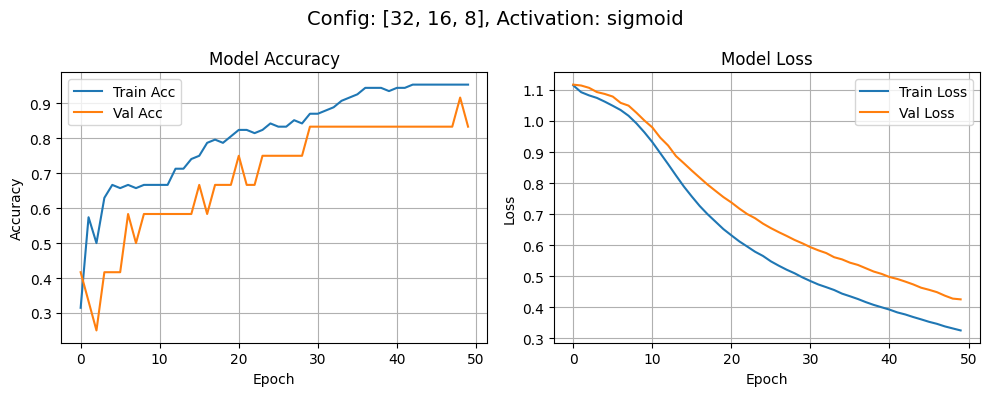


========== PREDICTION ==========
Predicted Iris Species: setosa
Prediction Probabilities: [0.8887238  0.10432812 0.00694805]


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)

classes = iris.target_names

# One-hot encode target values
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# Standardize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Function to create MLP model
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()

    model.add(
        Dense(
            hidden_layers[0],
            input_dim=input_dim,
            activation=activation
        )
    )

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))

    model.add(Dense(output_dim, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Different hidden layer configurations
hidden_layer_configs = [
    [8],
    [16, 8],
    [32, 16, 8]
]

# Different activation functions
activations = [
    'relu',
    'tanh',
    'sigmoid'
]

# Store results
results = []

# Train and evaluate different MLP configurations
for hidden_layers in hidden_layer_configs:

    for activation in activations:

        print(
            f"\nTesting MLP with hidden_layers={hidden_layers}, "
            f"activation={activation}"
        )

        # Create model
        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        # Train model
        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        # Evaluate model
        test_loss, test_acc = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

        # Store results
        results.append({
            'hidden_layers': hidden_layers,
            'activation': activation,
            'accuracy': test_acc,
            'loss': test_loss
        })

# Display all results
print("\n========== FINAL RESULTS ==========")

for result in results:
    print(
        f"Hidden Layers: {result['hidden_layers']}, "
        f"Activation: {result['activation']}, "
        f"Accuracy: {result['accuracy']:.4f}, "
        f"Loss: {result['loss']:.4f}"
    )


# Plot accuracy and loss curves
plt.figure(figsize=(10, 4))

plt.suptitle(
    f"Config: {hidden_layers}, Activation: {activation}",
    fontsize=14
)

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Train Acc'
)

plt.plot(
    history.history['val_accuracy'],
    label='Val Acc'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Prediction on a new Iris flower
# Example values:
# Sepal Length = 5.1 cm
# Sepal Width  = 3.5 cm
# Petal Length = 1.4 cm
# Petal Width  = 0.2 cm

sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 0.2

# Create input array
user_input = np.array([
    [
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]
])

# Scale input using the same scaler
user_input_scaled = scaler.transform(user_input)

# Predict using the last trained model
prediction = model.predict(
    user_input_scaled,
    verbose=0
)

# Get predicted class index
predicted_class_index = np.argmax(prediction)

# Get predicted class name
predicted_class_name = classes[predicted_class_index]

print("\n========== PREDICTION ==========")
print(f"Predicted Iris Species: {predicted_class_name}")
print(f"Prediction Probabilities: {prediction[0]}")